In [15]:
!pip install -q --upgrade keras-cv tensorflow roboflow

import os
import json
import tensorflow as tf
import keras_cv
import matplotlib.pyplot as plt
from roboflow import Roboflow

# --- 1. DOWNLOAD DATASET ---
rf = Roboflow(api_key="rlFp0Gl96481slJPZ8y6")
project = rf.workspace("dddddddd-0jtur").project("drones-kaggle")
version = project.version(2)
dataset = version.download("coco")

# Configuration
IMG_SIZE = 640
BATCH_SIZE = 4
MAX_BOXES = 10

loading Roboflow workspace...
loading Roboflow project...


In [16]:
# --- 2. DATA LOADER ---
def load_data(img_path, box, cls):
    image = tf.io.read_file(img_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    box = tf.cast(tf.reshape(box, [-1, 4]), tf.float32)
    cls = tf.cast([cls], tf.int32)

    pad_len = tf.maximum(0, MAX_BOXES - tf.shape(box)[0])
    padded_boxes = tf.pad(box, [[0, pad_len], [0, 0]], constant_values=-1.0)
    padded_classes = tf.pad(cls, [[0, MAX_BOXES - tf.shape(cls)[0]]], constant_values=-1)

    return {
        "images": tf.cast(image, tf.float32),
        "bounding_boxes": {"boxes": padded_boxes[:MAX_BOXES], "classes": padded_classes[:MAX_BOXES]}
    }

# Map dataset paths
with open(os.path.join(dataset.location, "train/_annotations.coco.json")) as f:
    coco = json.load(f)

img_map = {i['id']: os.path.join(dataset.location, "train", i['file_name']) for i in coco['images']}
paths, bboxes, classes = [], [], []
for ann in coco['annotations']:
    paths.append(img_map[ann['image_id']])
    bboxes.append(ann['bbox'])
    classes.append(0)

train_ds = tf.data.Dataset.from_tensor_slices((paths, bboxes, classes))
train_ds = train_ds.map(load_data).shuffle(100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- 3. CUSTOM RETINANET MODEL ---
backbone = keras_cv.models.ResNet50Backbone.from_preset("resnet50_imagenet")
model = keras_cv.models.RetinaNet(
    num_classes=1,
    bounding_box_format="xywh",
    backbone=backbone,
)

model.compile(
    classification_loss='focal',
    box_loss='smoothl1',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4)
)

print("Starting training...")
model.fit(train_ds.take(15), epochs=10)

Starting training...
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 104s 508ms/step - box_loss: 0.6286 - classification_loss: 0.8431 - loss: 1.4717
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 526ms/step - box_loss: 0.4919 - classification_loss: 0.5308 - loss: 1.0227
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 540ms/step - box_loss: 0.4330 - classification_loss: 0.2965 - loss: 0.7294
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 563ms/step - box_loss: 0.3545 - classification_loss: 0.3075 - loss: 0.6620
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 565ms/step - box_loss: 0.3285 - classification_loss: 0.3134 - loss: 0.6419
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 541ms/step - box_loss: 0.2780 - classification_loss: 0.1939 - loss: 0.4719
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 532ms/step - box_loss: 0.2450 - classification_loss: 0.2002 - loss: 0.4453
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 519ms/step - box_loss: 0.2274 - classification_loss: 0.2009 - loss: 0.4284
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 515ms/st

The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(4, 640, 640, 3))


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


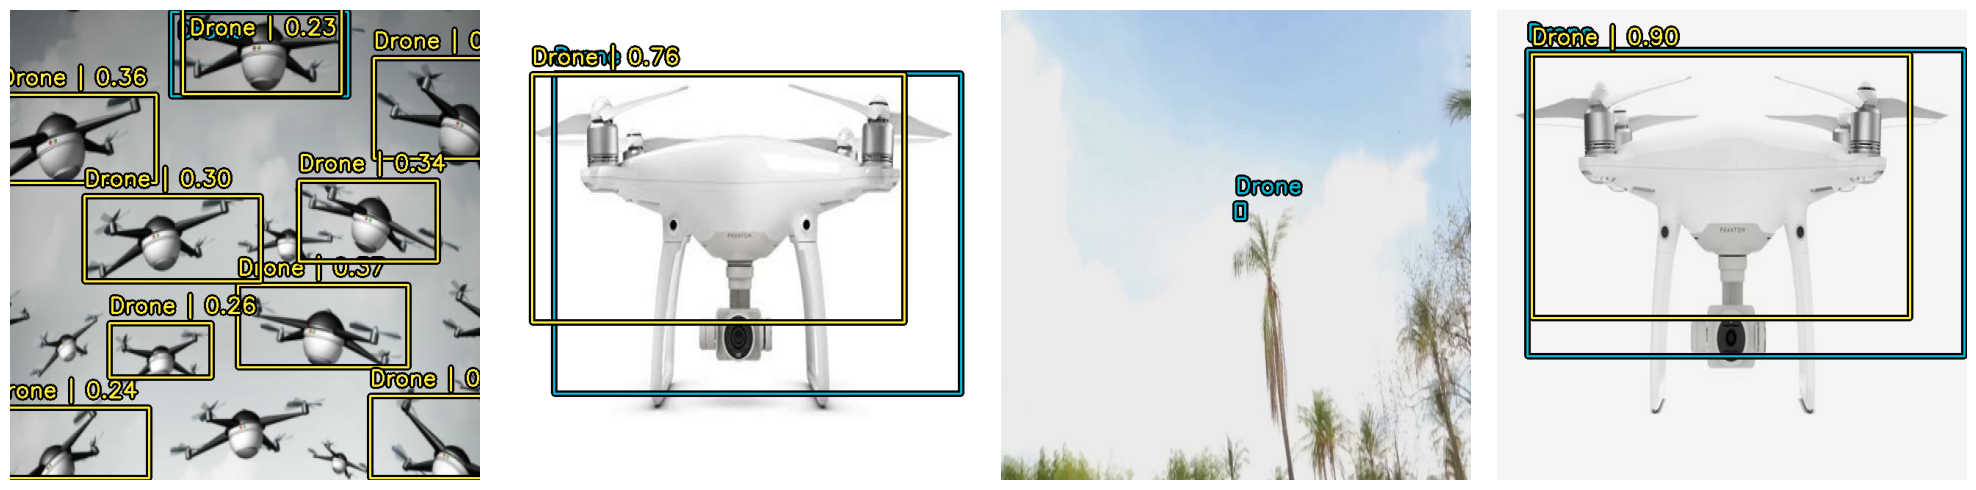

Model saved as drone_model.weights.h5


In [17]:
# --- 4. PREDICTION DECODER ---
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,
    iou_threshold=0.3,
    confidence_threshold=0.2,
)

# --- 5. TEST & VISUALIZE ---
# Grab a sample from the dataset
sample_data = next(iter(train_ds.take(1)))
images = sample_data["images"]
y_true = sample_data["bounding_boxes"]

# Predict
y_pred = model.predict(images)

# Plot Results
keras_cv.visualization.plot_bounding_box_gallery(
    images,
    value_range=(0, 255),
    rows=1,
    cols=BATCH_SIZE,
    y_true=y_true,   # Blue boxes (Dataset Labels)
    y_pred=y_pred,   # Yellow boxes (Model Detections)
    scale=5,
    bounding_box_format="xywh",
    class_mapping={0: "Drone"},
)
plt.show()

# --- 6. SAVE MODEL ---
model.save_weights("drone_model.weights.h5")
print("Model saved as drone_model.weights.h5")

In [1]:
import streamlit as st
import numpy as np
import cv2
from PIL import Image
from tensorflow.keras.models import load_model

# ---------------------------
# Load Model
# ---------------------------
@st.cache_resource
def load_retinanet_model():
    model = load_model("C:\Users\Arunnachalam\Downloads\ML DL GEN AI PROJECTS code\drone_model.weights.h5", compile=False)
    return model

model = load_retinanet_model()

# ---------------------------
# Preprocess Image
# ---------------------------
def preprocess_image(image):
    image = np.array(image)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = cv2.resize(image, (224, 224))  # change if needed
    image = image / 255.0
    image = np.expand_dims(image, axis=0)
    return image

# ---------------------------
# Dummy Decode Function (EDIT based on your model)
# ---------------------------
def decode_predictions(preds, original_image):
    image = original_image.copy()
    h, w, _ = image.shape

    # ⚠️ Replace this logic with your RetinaNet output decoding
    # Example: assuming [x1, y1, x2, y2, score]

    for pred in preds[0]:
        x1, y1, x2, y2, score = pred

        if score > 0.5:
            x1 = int(x1 * w)
            y1 = int(y1 * h)
            x2 = int(x2 * w)
            y2 = int(y2 * h)

            cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(image, f"Drone {score:.2f}",
                        (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (0,255,0), 2)

    return image

# ---------------------------
# Streamlit UI
# ---------------------------
st.set_page_config(page_title="Drone Detection 🚁", layout="centered")

st.title("🚁 Drone Detection using RetinaNet")
st.write("Upload an image and detect drones")

uploaded_file = st.file_uploader("Upload Image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)

    st.image(image, caption="Uploaded Image", use_column_width=True)

    if st.button("Detect Drone"):
        st.write("🔍 Detecting...")

        # Preprocess
        processed = preprocess_image(image)

        # Prediction
        preds = model.predict(processed)

        # Convert original image
        original = np.array(image)

        # Decode + Draw boxes
        output_image = decode_predictions(preds, original)

        st.image(output_image, caption="Detection Result", use_column_width=True)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (393809072.py, line 12)